# Introducción al aprendizaje automatizado (O2026)
## Tutorial 8 - Best Subset y Stepwise Selection

**Objetivo:**  
Que se familiaricen con los métodos de selección de variables: Best Subset, Forward Stepwise y Backward Stepwise.

Vamos a usar la base `Hitters` (la misma que van a usar en el notebook de Regularización).

In [1]:
import pandas as pd
import numpy as np
from ISLP import load_data

from matplotlib import pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from itertools import combinations

### Datos: Hitters (baseballistas)

Datos de la Major League de Baseball en las temporadas 1986 y 1987. Nuestro objetivo es **predecir el salario** de los jugadores.

Es la misma base que van a usar en el notebook de Regularización (Ridge, LASSO, Elastic Net).

In [2]:
Hitters = load_data('Hitters')
print('Dimensión original:', Hitters.shape)
print('Missings en Salary:', Hitters['Salary'].isnull().sum())

# Eliminamos filas sin salario
Hitters = Hitters.dropna().reset_index(drop=True)
print('Dimensión final:', Hitters.shape)

Dimensión original: (322, 20)
Missings en Salary: 59
Dimensión final: (263, 20)


In [3]:
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
3,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A


### Preparar X e Y
Separamos la variable dependiente (Salary) y creamos dummies para las categóricas.

In [4]:
y = Hitters['Salary']

# Creamos dummies para las variables categóricas
dummies = pd.get_dummies(Hitters[['League', 'Division', 'NewLeague']], drop_first=True)

# Armamos la matriz X con numéricas + dummies
X = Hitters.drop(['Salary', 'League', 'Division', 'NewLeague'], axis=1).astype('float64')
X = pd.concat([X, dummies.astype('float64')], axis=1)

print('Cantidad de predictores (p):', X.shape[1])
print('Cantidad de observaciones (n):', X.shape[0])
X.columns.tolist()

Cantidad de predictores (p): 19
Cantidad de observaciones (n): 263


['AtBat',
 'Hits',
 'HmRun',
 'Runs',
 'RBI',
 'Walks',
 'Years',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRuns',
 'CRBI',
 'CWalks',
 'PutOuts',
 'Assists',
 'Errors',
 'League_N',
 'Division_W',
 'NewLeague_N']

### Train / Test split
Separamos 70% para entrenamiento y 30% para testeo (igual que en el notebook de CV).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

print(f'Entrenamiento: {len(X_train)} observaciones')
print(f'Testeo: {len(X_test)} observaciones')

Entrenamiento: 184 observaciones
Testeo: 79 observaciones


---
## 1. Best Subset Selection

La idea es probar **todas** las combinaciones posibles de variables y quedarse con el mejor modelo de cada tamaño.

Con $p = 19$ predictores, el total de modelos posibles es $2^{19} = 524.288$. Es factible pero costoso.

Para simplificar, vamos a hacer Best Subset hasta un máximo de variables (por ejemplo, hasta 10).

In [6]:
def best_subset(X_train, y_train, max_vars=10):
    '''
    Para cada tamaño k (de 1 a max_vars), encuentra el mejor subconjunto 
    de k variables (el que tiene menor RSS en la muestra de entrenamiento).
    
    Devuelve un diccionario con el mejor modelo de cada tamaño.
    '''
    resultados = {}
    todas_las_vars = X_train.columns.tolist()
    
    for k in range(1, max_vars + 1):
        mejor_rss = np.inf
        mejor_vars = None
        
        # Probar todas las combinaciones de k variables
        for combo in combinations(todas_las_vars, k):
            modelo = LinearRegression().fit(X_train[list(combo)], y_train)
            rss = np.sum((y_train - modelo.predict(X_train[list(combo)]))**2)
            
            if rss < mejor_rss:
                mejor_rss = rss
                mejor_vars = list(combo)
        
        resultados[k] = {'variables': mejor_vars, 'rss_train': mejor_rss}
        print(f'k={k}: {len(list(combinations(todas_las_vars, k)))} modelos evaluados -> mejores vars: {mejor_vars}')
    
    return resultados

In [7]:
# Esto tarda un poco porque prueba muchas combinaciones
# Con max_vars=4 es rápido; con max_vars=10 tarda ~1 min
best_models = best_subset(X_train, y_train, max_vars=4)

k=1: 19 modelos evaluados -> mejores vars: ['CRBI']
k=2: 171 modelos evaluados -> mejores vars: ['Hits', 'CRBI']
k=3: 969 modelos evaluados -> mejores vars: ['AtBat', 'Hits', 'CRBI']
k=4: 3876 modelos evaluados -> mejores vars: ['Hits', 'CAtBat', 'CHits', 'CHmRun']


#### Elegir el mejor tamaño con MSE de testeo
Ahora evaluamos cada modelo en la **muestra de testeo** para elegir cuántas variables incluir.

In [8]:
mse_best = []

for k, info in best_models.items():
    vars_k = info['variables']
    modelo = LinearRegression().fit(X_train[vars_k], y_train)
    y_pred = modelo.predict(X_test[vars_k])
    mse = mean_squared_error(y_test, y_pred)
    mse_best.append({'k': k, 'mse_test': mse, 'variables': vars_k})

df_best = pd.DataFrame(mse_best)
df_best

,k,mse_test,variables
0,1,153365.793604,[CRBI]
1,2,127222.550716,"[Hits, CRBI]"
2,3,134595.405158,"[AtBat, Hits, CRBI]"
3,4,136006.809546,"[Hits, CAtBat, CHits, CHmRun]"


In [9]:
# Mejor modelo según MSE de testeo
mejor = df_best.loc[df_best['mse_test'].idxmin()]
print(f"Mejor modelo: k={int(mejor['k'])} variables")
print(f"MSE test: {mejor['mse_test']:.2f}")
print(f"Variables: {mejor['variables']}")

Mejor modelo: k=2 variables
MSE test: 127222.55
Variables: ['Hits', 'CRBI']


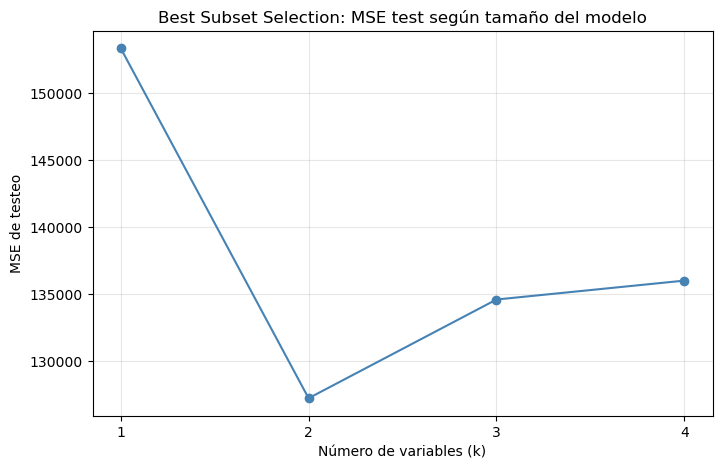

In [10]:
# Gráfico: MSE test vs número de variables
plt.figure(figsize=(8, 5))
plt.plot(df_best['k'], df_best['mse_test'], 'o-', color='steelblue')
plt.xlabel('Número de variables (k)')
plt.ylabel('MSE de testeo')
plt.title('Best Subset Selection: MSE test según tamaño del modelo')
plt.xticks(df_best['k'])
plt.grid(True, alpha=0.3)
plt.show()

#### Limitación de Best Subset

Con $p = 19$ y `max_vars=4`, ya estamos evaluando miles de modelos. Si quisiéramos ir hasta $k=19$, serían $2^{19} \approx 524.000$ modelos.

**Pregunta para pensar:** ¿Qué pasa si tenemos $p = 100$ o $p = 284$ variables (como en Belloni et al., 2014)?

---
## 2. Forward Stepwise Selection

En lugar de probar todas las combinaciones, **empezamos de cero** y vamos agregando variables de a una: en cada paso, agregamos la que más reduce el RSS.

In [11]:
def forward_stepwise(X_train, y_train):
    '''
    Forward Stepwise Selection.
    Empieza sin variables y agrega de a una la que más reduce el RSS.
    '''
    todas_las_vars = X_train.columns.tolist()
    incluidas = []
    resultados = {}
    
    for k in range(1, len(todas_las_vars) + 1):
        mejor_rss = np.inf
        mejor_var = None
        
        # Probar agregar cada variable que aún no está incluida
        for var in todas_las_vars:
            if var not in incluidas:
                candidatas = incluidas + [var]
                modelo = LinearRegression().fit(X_train[candidatas], y_train)
                rss = np.sum((y_train - modelo.predict(X_train[candidatas]))**2)
                
                if rss < mejor_rss:
                    mejor_rss = rss
                    mejor_var = var
        
        incluidas.append(mejor_var)
        resultados[k] = {'variables': incluidas.copy(), 'rss_train': mejor_rss}
    
    return resultados

In [12]:
fwd_models = forward_stepwise(X_train, y_train)

# Veamos el orden en que se agregan las variables
print('Orden de entrada de variables (Forward):')
for k in range(1, len(fwd_models) + 1):
    nueva = fwd_models[k]['variables'][-1]  # última variable agregada
    print(f'  Paso {k}: + {nueva}')

Orden de entrada de variables (Forward):
  Paso 1: + CRBI
  Paso 2: + Hits
  Paso 3: + AtBat
  Paso 4: + Walks
  Paso 5: + PutOuts
  Paso 6: + Division_W
  Paso 7: + Years
  Paso 8: + CRuns
  Paso 9: + CWalks
  Paso 10: + CAtBat
  Paso 11: + Assists
  Paso 12: + RBI
  Paso 13: + NewLeague_N
  Paso 14: + Runs
  Paso 15: + HmRun
  Paso 16: + Errors
  Paso 17: + CHits
  Paso 18: + CHmRun
  Paso 19: + League_N


---
## 3. Backward Stepwise Selection

Lo opuesto: **empezamos con todas** las variables y vamos sacando de a una la que menos aporta.

In [13]:
def backward_stepwise(X_train, y_train):
    '''
    Backward Stepwise Selection.
    Empieza con todas las variables y saca de a una la que menos aporta.
    '''
    incluidas = X_train.columns.tolist()
    resultados = {}
    p = len(incluidas)
    
    # Modelo completo
    modelo_full = LinearRegression().fit(X_train[incluidas], y_train)
    rss_full = np.sum((y_train - modelo_full.predict(X_train[incluidas]))**2)
    resultados[p] = {'variables': incluidas.copy(), 'rss_train': rss_full}
    
    for k in range(p, 1, -1):
        mejor_rss = np.inf
        peor_var = None
        
        # Probar sacar cada variable que está incluida
        for var in incluidas:
            candidatas = [v for v in incluidas if v != var]
            modelo = LinearRegression().fit(X_train[candidatas], y_train)
            rss = np.sum((y_train - modelo.predict(X_train[candidatas]))**2)
            
            if rss < mejor_rss:
                mejor_rss = rss
                peor_var = var
        
        incluidas.remove(peor_var)
        resultados[k - 1] = {'variables': incluidas.copy(), 'rss_train': mejor_rss}
    
    return resultados

In [14]:
bwd_models = backward_stepwise(X_train, y_train)

# Veamos el orden en que se sacan las variables
print('Orden de salida de variables (Backward):')
p = len(X_train.columns)
for k in range(p, 1, -1):
    vars_antes = set(bwd_models[k]['variables'])
    vars_despues = set(bwd_models[k-1]['variables'])
    sacada = vars_antes - vars_despues
    print(f'  Paso {p - k + 1}: - {sacada.pop()}')

Orden de salida de variables (Backward):
  Paso 1: - Years
  Paso 2: - League_N
  Paso 3: - CHmRun
  Paso 4: - CHits
  Paso 5: - Errors
  Paso 6: - HmRun
  Paso 7: - Runs
  Paso 8: - NewLeague_N
  Paso 9: - RBI
  Paso 10: - Division_W
  Paso 11: - Assists
  Paso 12: - CAtBat
  Paso 13: - CRuns
  Paso 14: - CWalks
  Paso 15: - PutOuts
  Paso 16: - Walks
  Paso 17: - AtBat
  Paso 18: - Hits


---
## 4. Comparación de los tres métodos

Evaluamos el MSE de testeo para cada tamaño de modelo en los tres métodos.

In [15]:
def evaluar_en_test(modelos, X_train, X_test, y_train, y_test):
    '''Calcula el MSE de testeo para cada modelo de la secuencia.'''
    resultados = []
    for k, info in sorted(modelos.items()):
        vars_k = info['variables']
        modelo = LinearRegression().fit(X_train[vars_k], y_train)
        y_pred = modelo.predict(X_test[vars_k])
        mse = mean_squared_error(y_test, y_pred)
        resultados.append({'k': k, 'mse_test': mse})
    return pd.DataFrame(resultados)

In [16]:
mse_fwd = evaluar_en_test(fwd_models, X_train, X_test, y_train, y_test)
mse_bwd = evaluar_en_test(bwd_models, X_train, X_test, y_train, y_test)

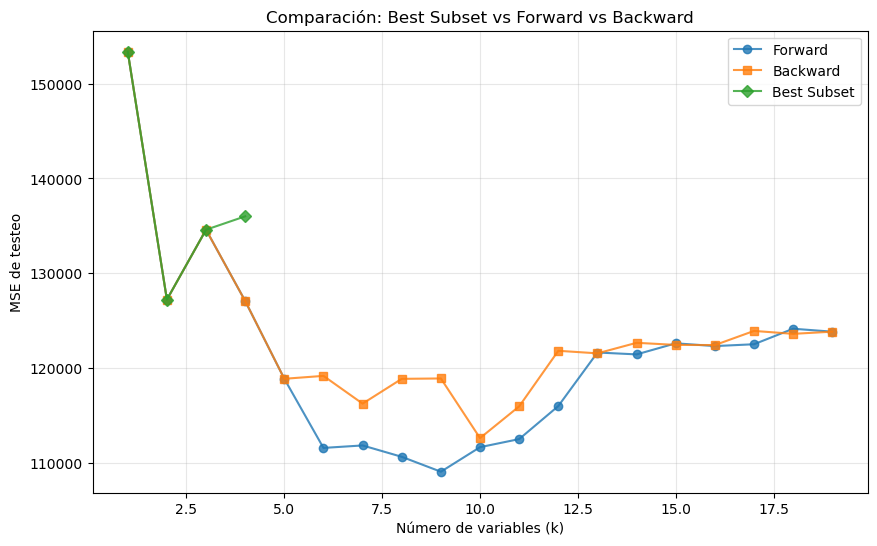

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(mse_fwd['k'], mse_fwd['mse_test'], 'o-', label='Forward', alpha=0.8)
plt.plot(mse_bwd['k'], mse_bwd['mse_test'], 's-', label='Backward', alpha=0.8)

# Agregar Best Subset si lo corrimos
if len(df_best) > 0:
    plt.plot(df_best['k'], df_best['mse_test'], 'D-', label='Best Subset', alpha=0.8)

plt.xlabel('Número de variables (k)')
plt.ylabel('MSE de testeo')
plt.title('Comparación: Best Subset vs Forward vs Backward')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Mejor modelo de cada método
mejor_fwd = mse_fwd.loc[mse_fwd['mse_test'].idxmin()]
mejor_bwd = mse_bwd.loc[mse_bwd['mse_test'].idxmin()]

print(f"Forward:  k={int(mejor_fwd['k'])}, MSE test={mejor_fwd['mse_test']:.2f}")
print(f"Backward: k={int(mejor_bwd['k'])}, MSE test={mejor_bwd['mse_test']:.2f}")

print(f"\nVariables del mejor modelo Forward:")
print(fwd_models[int(mejor_fwd['k'])]['variables'])

print(f"\nVariables del mejor modelo Backward:")
print(bwd_models[int(mejor_bwd['k'])]['variables'])

Forward:  k=9, MSE test=109074.77
Backward: k=10, MSE test=112619.98

Variables del mejor modelo Forward:
['CRBI', 'Hits', 'AtBat', 'Walks', 'PutOuts', 'Division_W', 'Years', 'CRuns', 'CWalks']

Variables del mejor modelo Backward:
['AtBat', 'Hits', 'Walks', 'CAtBat', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists', 'Division_W']


#### ¿Forward y Backward eligen las mismas variables?

No necesariamente. Como son algoritmos *greedy* (toman la mejor decisión en cada paso sin volver atrás), pueden llegar a soluciones distintas o iguales

In [19]:
# Comparamos las variables elegidas por Forward y Backward para k=5
k_comparar = 5
vars_fwd = set(fwd_models[k_comparar]['variables'])
vars_bwd = set(bwd_models[k_comparar]['variables'])

print(f'Variables en Forward (k={k_comparar}):  {vars_fwd}')
print(f'Variables en Backward (k={k_comparar}): {vars_bwd}')
print(f'\nEn común: {vars_fwd & vars_bwd}')
print(f'Solo en Forward: {vars_fwd - vars_bwd}')
print(f'Solo en Backward: {vars_bwd - vars_fwd}')

Variables en Forward (k=5):  {'AtBat', 'Walks', 'CRBI', 'Hits', 'PutOuts'}
Variables en Backward (k=5): {'AtBat', 'Walks', 'CRBI', 'Hits', 'PutOuts'}

En común: {'AtBat', 'Walks', 'CRBI', 'Hits', 'PutOuts'}
Solo en Forward: set()
Solo en Backward: set()


---
## 5. Resumen y conexión con lo que viene

| Método | Ventaja | Limitación |
|--------|---------|------------|
| **Best Subset** | Encuentra el óptimo global | Inviable si $p$ es grande ($2^p$ modelos) |
| **Forward** | Rápido, funciona con $p > n$ | Greedy: no garantiza el óptimo |
| **Backward** | Rápido | Requiere $n > p$ |

### ¿Qué viene en las próximas clases?

**LASSO** resuelve el mismo problema (seleccionar variables) pero de forma continua y más eficiente. En vez de incluir/excluir variables, achica los coeficientes y algunos los lleva exactamente a cero.


##### Tarea para la casa:
- Usar **K-Fold CV** (en vez de un solo train/test split) para elegir el número óptimo de variables en Forward Stepwise. ¿Cambia el resultado?
- Comparar el MSE del mejor modelo de Forward con el MSE del modelo de LASSO del notebook de Regularización.